# 퍼셉트론 & 딥러닝 기초

## 1. 인공신경망의 시작: 퍼셉트론

### 1-1. 인공신경망이란?
**인공신경망**: 우리 뇌의 신경망을 모방한 모델  
- 뉴런이 전기신호를 통해 정보를 처리하는 구조를 모방
- 퍼셉트론을 연결시켜 입력값에 가중치와 편향을 적용
- 임계값을 넘었을 때, 유의미한 값으로 판단하여 Output 출력
  
**퍼셉트론**: 초기 형태의 인공신경망, 딥러닝의 기원이 되는 선형 이진 분류기  
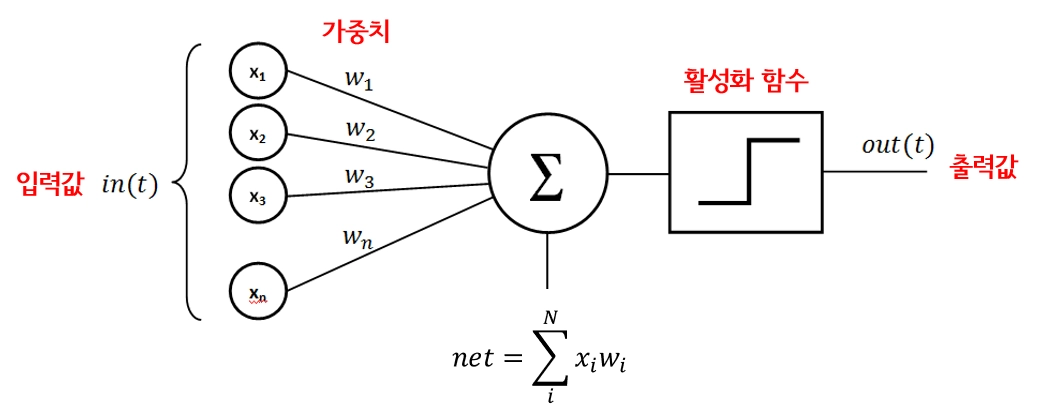  
  
- 입력 -> 가중합 -> 활성화 함수 -> 출력
    1. 입력치*가중치
    2. sum(입력치*가중치)
    3. if 총합 > 임계값 -> 1, else 0
- 활성화 함수: 임계값 초과 여부에 따라 출력값 결정 (어떤 활성화 함수를 사용하는지로 출력값을 조절)
- Training: 원하는 출력값을 내보내도록 가중치를 조정해가는 과정
  
> 용어 정리  
  
1. 가중치: $w_1, w_2, ... w_n$  
- 입력값이 출력값이 주는 영향력(중요도) 결정
- 각 입력값에는 각각의 가중치 존재
- 가중치 클수록 해당 입력값이 중요함을 의미
  
2. 활성화 함수
- 신호가 일정 이상의 값(임계값)을 넘으면 1, 넘지 못하면 0을 출력하는 퍼셉트론의 성질은 활성화함수로 '계단 함수' 사용 
  
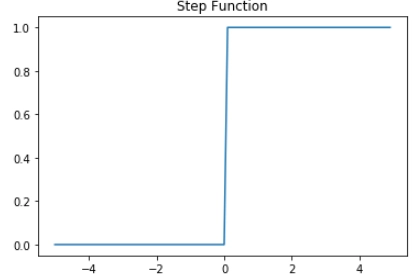  
  
- 이외에도 Sigmoid, Tanh, ReLU, leaky ReLU 등 다양한 활성화 함수 존재
  
3. 임계값
- 활성화 함수에 사용되는 값으로 보통 세타($\theta$)로 표현
- 계단 함수의 경우 가중합이 임계값 넘으면 1, 넘지 못하면 0 출력
  
4. 편향
- 임계값을 좌변으로 넘겨 편향으로 표현 가능
- 가중합+편향>=0 -> y=1  
  
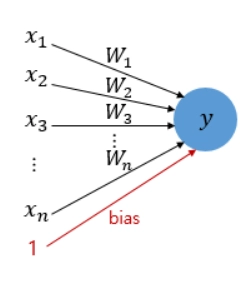  
  
- 입력값 1에 편향 b 곱해진 형태로 표현
- 임계값과 편향은 표현의 차이
  
  
### 1-2. 단층 퍼셉트론과 그 한계 
  
**단층 퍼셉트론**: 단순히 입력층과 출력층으로만 이루어진 퍼셉트론  
  
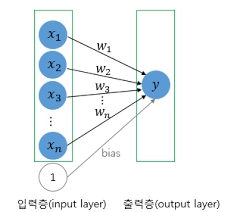  
  
- 값을 보내는 단계, 값을 받아서 출력하는 단계로 구성
  
**논리 게이트**  
- 단층 퍼셉트론을 이용해 AND, NAND, OR 논리 게이트 쉽게 구현 가능
- 디지털 회로에서 기본적인 논리 연산을 수행하는 데 사용되는 구성 요소
- n개의 입력값과 하나의 출력값이 게이트 연산에 쓰임
- AND, OR, NOT, NAND, NOR, XOR 등 다양한 종류가 있으며, 이 논리 게이트를 조합하여 복잡한 논리 회로 구성
  
1. AND 게이트: 입력값이 모두 1인 경우에만 출력값 1이 나오는 구조
  
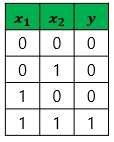  
  
2. OR 게이트: 입력값이 모두 0인 경우에 출력값이 0, 나머지 경우에는 모두 출력값이 1
  
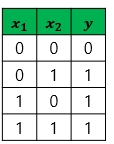  
  
3. NAND 게이트: 입력값이 모두 1인 경우에만 출력값이 0, 나머지 경우에는 모두 출력값이 1인 구조  
  
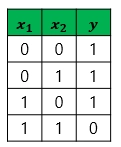  
  
4. XOR 게이트: 입력값 두 개가 서로 다른 값을 갖고 있을 때만 출력값이 1인 구조  
  
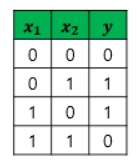  
  
**단측 퍼셉트론의 한계**  
- XOR 게이트를 구현할 수 없음
    - 퍼셉트론은 선형적이기 때문에 직선 하나루 두 영역을 나눌 수 있는 *선형 분류 문제*의 경우에만 구현가능 함
    - But XOR 게이트는 직선이 아닌 곡선/비선형 영역으로 분리해야만 구현 가능
    - 퍼셉트론을 여러 계층올 쓰면 구현 가능
  
  
### 1-3. 다층 퍼셉트론  
  
기존의 AND, NAND, OR 게이트를 조합해 XOR 게이트를 만들 수 있음  
  
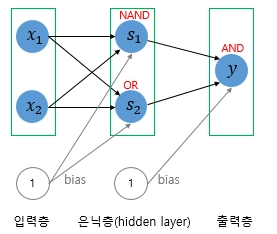  
  
- 중간에 층을 추가하여 구성 (입력층 + 하나 이상의 은닉층 + 출력층)
- 두 개 이상의 은닉층을 갖는 MLP가 딥러닝의 시초 모델로 발전
    - 심층 신경망 (DNN): 은닉층이 2개 이상인 신경망
    - 딥러닝: 심층 신경망을 학습(가중치를 스스로 찾도록) 시킴

## 2. 딥러닝 모델은 어떻게 학습할까?  
  
### 2-1. 순전파와 역전파  
  
> 학습 알고리즘의 기본 구조  
  
1. 순전파를 통해 입력값으로부터 예측 수행 (순전파: 입력층->정답)
2. 오차 계산을 통해 예측 정확도 측정 
3. 역전파를 통해 출력층에서 다시 입력층 방향으로 오차 전달 (역전파: 정답->입력층)
4. 가중치 업데이트
5. 위 과정을 반복하여 오차값이 0에 가까워지도록 수정
  
  
**연쇄 법칙**: 합성함수의 미분은 각 함수의 미분의 곱으로 나타낼 수 있다는 법칙  
- 각 단계가 연쇄적으로 결과에 얼마나 영향을 줬는지 확인
    - 입력값이 여러 은닉층을 거친 후 최종 출력값이 나오는데, 이때 입력값이 최종 출력에 얼마나 영향을 미쳤는지 계산하려면 *각 층이 다음 층에 미친 영향을 순서대로 곱해야 함*
- 딥러닝 모델을 학습시키기 위해 각 가중치가 최종 손실에 얼마나 기여했는지 계산
- A->B->C로 이어지는 3층 구조에서 A는 B에 영향을, B는 C의 영향을 줌
    - 이때, A가 C에 미친 영향은 직접 계산할 수 없고, 분해해서 구해야 함.
        $\frac{∂C}{∂A}=\frac{∂C}{∂B}×\frac{∂B}{∂A}$
    - A->C의 영향 = B->C의 영향 * A->B의 영향
- 딥러닝 모델의 성능을 높이려면, 모델의 오차를 계산해 오차를 줄이는 것이 필요
- 손실 함수: 오차값과 실제값을 수치로 표현
    - 연쇄법칙을 통해 구하는 기울기 = '손실 함수를 줄이기 위해 가중치를 어떻게 바꿀지' 알려주는 신호

  
  
**기울기 소실 문제**  
if) 은닉층도 엄청 많고, 각 단계마다 미분값이 1보다 작은 값이라면  
-> 한없이 0에 가까워짐  
  
*즉, 기울기 소실 문제란, 기울기를 계속해서 곱했는데, 결국 기울기가 0이되는 문제*  
  
- 앞쪽 층의 가중치가 거의 업데이트되지 않아서 학습이 제대로 이뤄지지 않은 문제 발생  
  
> 전체적인 흐름 정리  
  
1. 순전파=예측하기
2. 손실 계산=얼마나 틀렸는지 측정하기
3. 역전파=책임 추적하기 (연쇄법칙 사용-각 가중치는 손실에 간접적으로 기여하고 있음)
4. 가중치 업데이트=수정하기  
-> 이 과정을 반복하며 모델의 정확도 개선  
  
### 2-2. 손실 함수  
  
**손실 함수**: 모델이 정확한지 오차를 계산하는 방법  
- 주로 회귀에서는 평균 제곱오차, 분류에서는 크로스 엔트로피 오차를 사용
  
1. 평균 제곱 오차 (MSE) 
  
$\frac{1}{N}\sum(y-\hat{y})^2$  
  
- 예측값이 연속적이고, 예측값과 실제값 간의 차이를 직접적으로 측정
- 회귀 문제에 적합
  
2. 이진 크로스 엔트로피 (BCE)  
  
$L= -(y \log \hat{y} + (1-y) \log(1-\hat{y}))$  
  
- 이진 분류 문제(로지스틱 회귀)에서 활용하는 손실 함수
- 실제 정답이 1일 때, 수식에서 y=1 대입하면 L=-log(y_hat)만 남음
    - 예측 확률이 1에 가까울수록 -> loss값은 0에 가까워짐
    - 예측 확률이 0에 가까워질수록 -> loss가 급격히 증가
- 실제 정답이 0일때, 수식에 0을 대입하면 L=-log(1-(y_hat))만 남음
    - 예측 확률이 0에 가까울수록 -> loss값은 0에 가까워짐
    - 예측 확률이 1에 가까울수록 -> loss가 급격히 증가
- 얼마나 확신을 가지고 예측했는지 loss에 반영함
  
3. 크로스 엔트로피 오차
  
$-\sum y \log \hat{y}$  
  
- 다중 클래스 분류 문제에서 예측 확률이 실제 클래스와 얼마나 일치하는 지를 평가
- 두 확률 분포의 유사도를 측정하는 데 유용
- 손실 함수와 유사하지만 다중 분류에서 사용
  
  
### 2-3. 활성화 함수  
  
**활성화 함수**  
  
신경망의 각 층의 계산 과정  
``` 입력값 * 가중치 + 편향 -> 활성화 함수 -> 출력값 ```  
  
- 이때 활성화 함수가 없으면, 층을 아무리 많이 쌓아도 선형 계산의 반족에 불과
    - XOR 같은 복잡한 패턴 학습 불과
- 활성화 함수는 각 층의 출력값에 비선형성을 추가해서 신경망이 복잡한 패턴도 학습할 수 있게 해주는 함수  
  

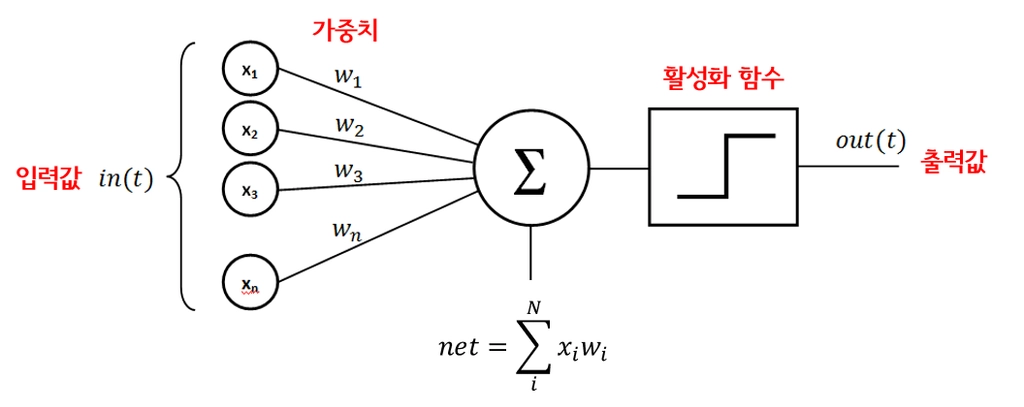  
  
  
- 가중치: 입력값이 결과에 얼마나 영향을 미치는 지를 결정하는 값
- 편향: 활성화 함수의 출력값을 조정하는 값, 기준점 역할을 수행
  
1. 계단함수  
  
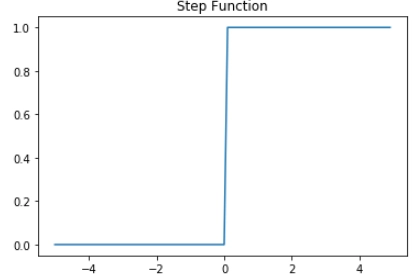  
  
$$h(x) = \begin{cases} 1 & (x \geq 0) \\ 0 & (x < 0) \end{cases}$$
  
- 입력값과 가중치의 값을 모두 더한 뒤, 그 합이 특정 기준을 넘으면 1, 아니면 0을 출력하는 함수
    - 임계값: 뉴런이 얼마나 쉽게 활성화되는지를 제어
    - 가중치: 각 입력 신호가 결과에 미치는 영향력 제어
- 주로 단층 퍼셉트론에서 사용
- 입력 신호: 입력값과 가중치의 곱
- 출력 신호: 0 또는 1
  
2. 시그모이드 함수  
  
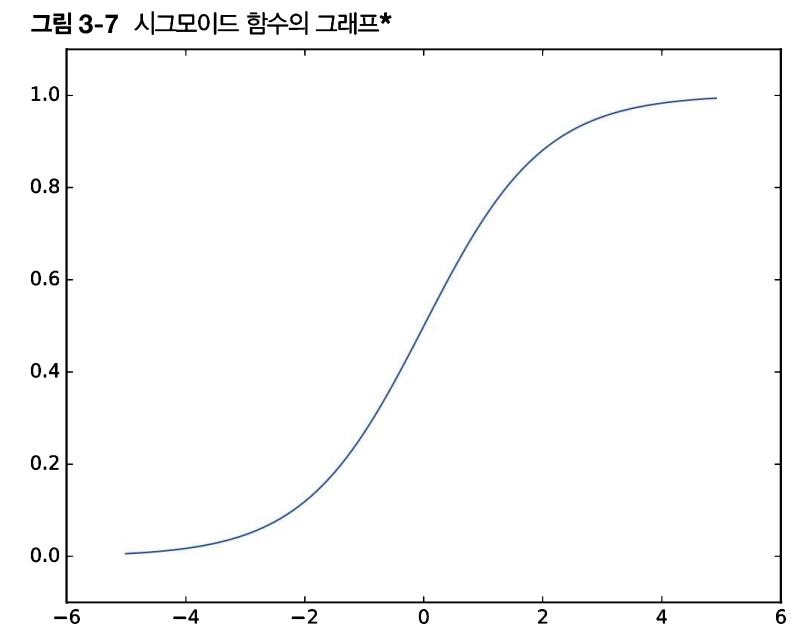  
  
$$f(x)=\frac{1}{1+e^{−x}}$$
  
- 입력 신호를 0과 1 사이의 연속적인 값으로 변환하는 비선형 함수
- 계단 함수와 달리 연속적인 값으로 출력됨
    - 맞다/틀리다가 아닌, 얼마나 확실한지를 표현할 수 있음
  
3. ReLU 함수  
  
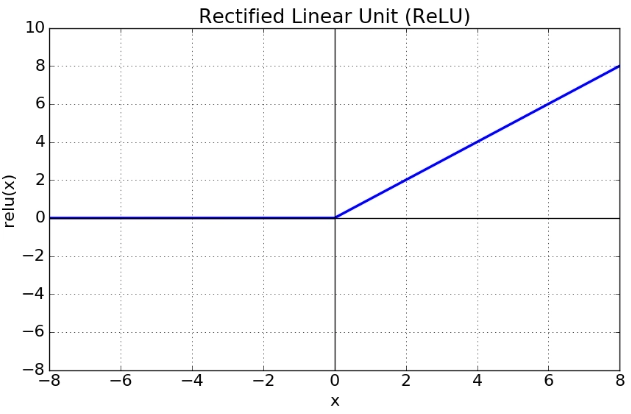  
  
$$f(x)=max(0,x)$$
  
- 은닉층 전반에서 활용
- 입력이 0보다 크면 해당 값 그대로, 0 이하면 0을 출력하는 비선형 함수
- 단순하지만 딥러닝에서 가장 많이 사용됨
    - 계산이 간단하고 효율적
    - 비선형성 제공
    - 기울기 소실 문제 완화 (양수 구간에서 미분값 항상 1이므로)
  
4. Tanh 함수  
  
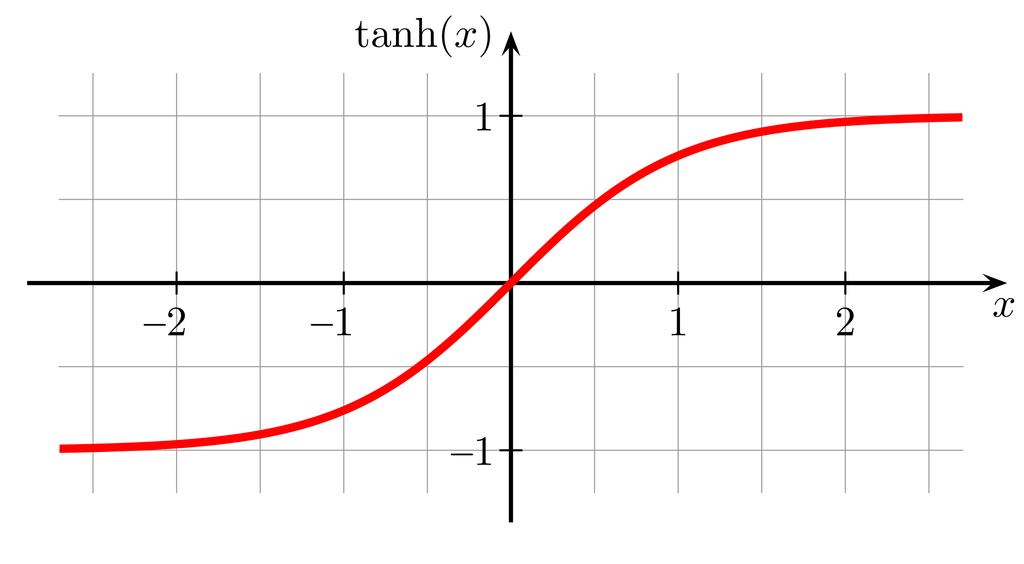  
  
$$f(x)=tanh(x)=\frac{e^x-e^{−x}}{e^x+e^{−x}}$$
  
- 은닉층에서 활용
- 시그모이드 함수의 변형
- -1~1 사이로 출력됨
- 시그모이드와 달리 중심이 0이므로, 입력값의 중심을 0으로 맞추고 싶을 때 사용
    - 중심이 0이면 가중치 업데이트가 더 안정적으로 이루어짐
- But, 입력값이 매우 크거나 작으면 미분값이 0에 가까워져 기울기 소실 문제 발생
  
5. Softmax 함수  
  
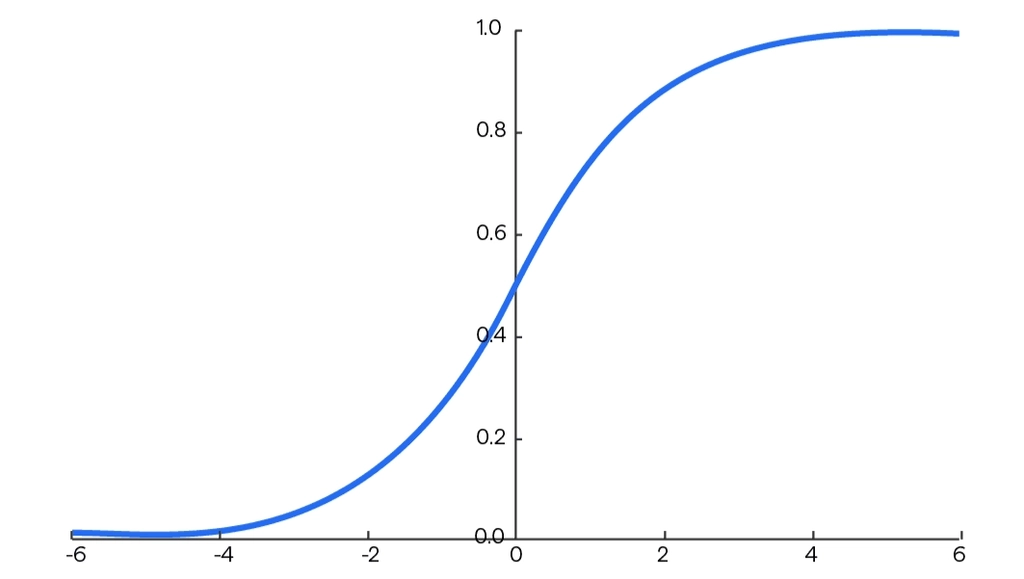  
  
$$f(x_i)=\frac{e^{x_i}}{∑_je^{x_j}}$$
  
- 각 클래스에 대한 출력값을 확률로 변환하는 함수
- 다중 클래스 분류 문제의 출력층에서 사용
    - 출력값이 모두 0~1 사이이고, 전체 합이 1이 되기 때문에 
- 손실 함수는 주로 크로스 엔트로피로 선택
    - 예측 확률(Softmax 함수)과 정답 확률과의 차이가 즉 크로스 엔트로피 손실 함수이기 때문
  

### 2-4. 경사하강법  
  
**경사하강법**: 손실 함수를 최소화하여 모델을 학습시키는 방법  
- 오차를 작게 만드는 가중치와 편향을 찾는 방법  
  
But, 데이터가 너무 방대하므로 학습 과정에서 모든 데이터를 한 번에 집어넣으면 메모리가 부족하고 시간이 오래 걸림  
-> 배치(Batch) 사용  
  
1. 배치(Batch)  
  
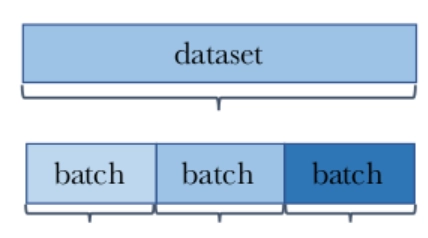  
  
- 학습 과정에서 가중치와 같은 매개변수를 조정하기 위해 사용하는 데이터의 묶음
- 사용자가 임의로 정할 수 있는 하이퍼파라미터
- 배치 크기가 너무 큰 경우, 학습 느려지고 메모리가 부족
- 배치 크기가 너무 작은 경우, 가중치가 자주 업데이트 되어 학습 불안정해짐
  
2. 에포크(Epoch)  
  
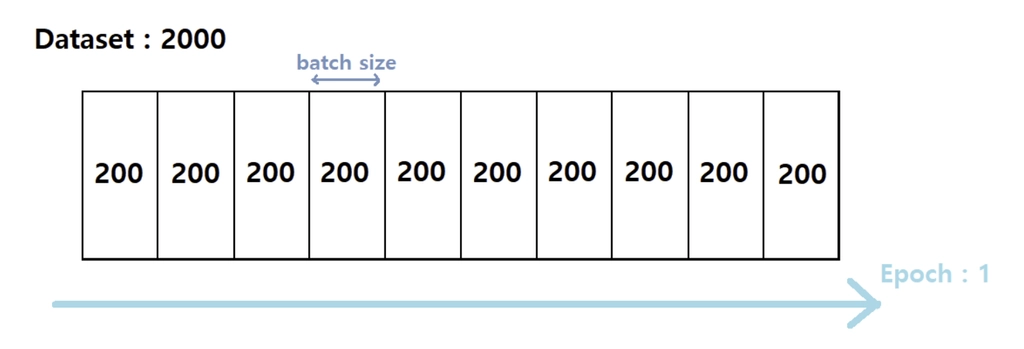  
  
- 모든 데이터셋을 학습하는 횟수
  
3. 이터레이션(Iteration) 또는 스텝(Step)  
- 한 번의 에포크를 끝내기 위해서 필요한 배치의 수
- 1 Epoch에서 다루는 데이터의 수 = 배치의 크기 * 이터레이션
    - ex. 전체 데이터 2000, 배치 크기를 200으로 하면, 이터레이션의 수는 총 10
  
> 경사하강법의 종류  
  
1. 배치 경사하강법: 가장 기본적인 경사하강법, 오차를 구할 때 전체 데이터를 한 묶음으로 묶음  
- 전체 데이터를 통해 학습시키기 때문에, 업데이트 횟수 적음 (1Epoch 당 1 업데이트)
- 전체 데이터를 모두 한 번에 처리 -> 메모리 많이 필요
- 항상 같은 데이터에 대해 경사를 구함 -> 수렴 안정적
- 시간이 오래 걸린다는 단점 존재
  
2. 배치 크기가 1인 확률적 경사하강법: 전체 데이터가 아닌, 랜덤으로 선택된 하나의 데이터에 대해서만 계산 
- 더 적은 데이터를 사용하므로 더 빠르게 계산 가능
- 자원이 적은 컴퓨터에서도 쉽게 사용 가능
- 매개변수의 변경폭 불안정, 정확도 낮을 수 있음
  
3. 미니 배치 경사하강법: 배치 크기를 적절히 지정하여 해당 데이터 개수만큼에 대해 매개 변수 값 조정
- 전체 데이터 계산하는 것보다는 빠르고, 배치 크기 1인 경사하강법보다는 안정적
- 가장 많이 사용됨
- 배치 크기는 일반적으로 $2^n$에 해당하는 숫자로 선택
- 만약 ```model.fit()```에서 배치 크기 별도로 지정해주지 않는다면, 기본값은 32
  
  
### 2-5. 옵티마이저  
  
경사하강법을 더욱 *효율적이고 안정적으로* 수행하기 위해서 필요  
  
1. 모멘텀: 변수가 가던 방향으로 계속 가도록 속도를 추가  
  
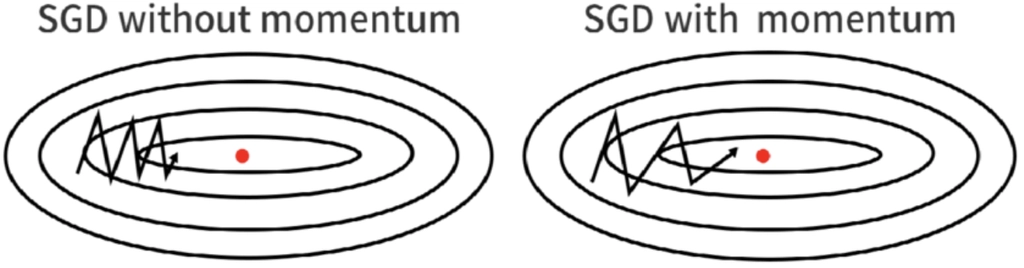  
  
- 경사하강법 + 관성
- 경사하강법에서 계산된 접선의 기울기에 바로 한 시점 전의 접선의 기울기값을 일정 비율만큼 반영
    - 중간에 Local minima에 빠지더라도 관성의 힘으로 넘어올 수 있음!
- 기울기 큰 방향에서는 너무 많이, 작은 방향에서는 너무 작게 이동한다는 문제
  
2. RMSProp: 각 학습률을 조정하여 안정적이고 빠르게 학습하도록 함  
  
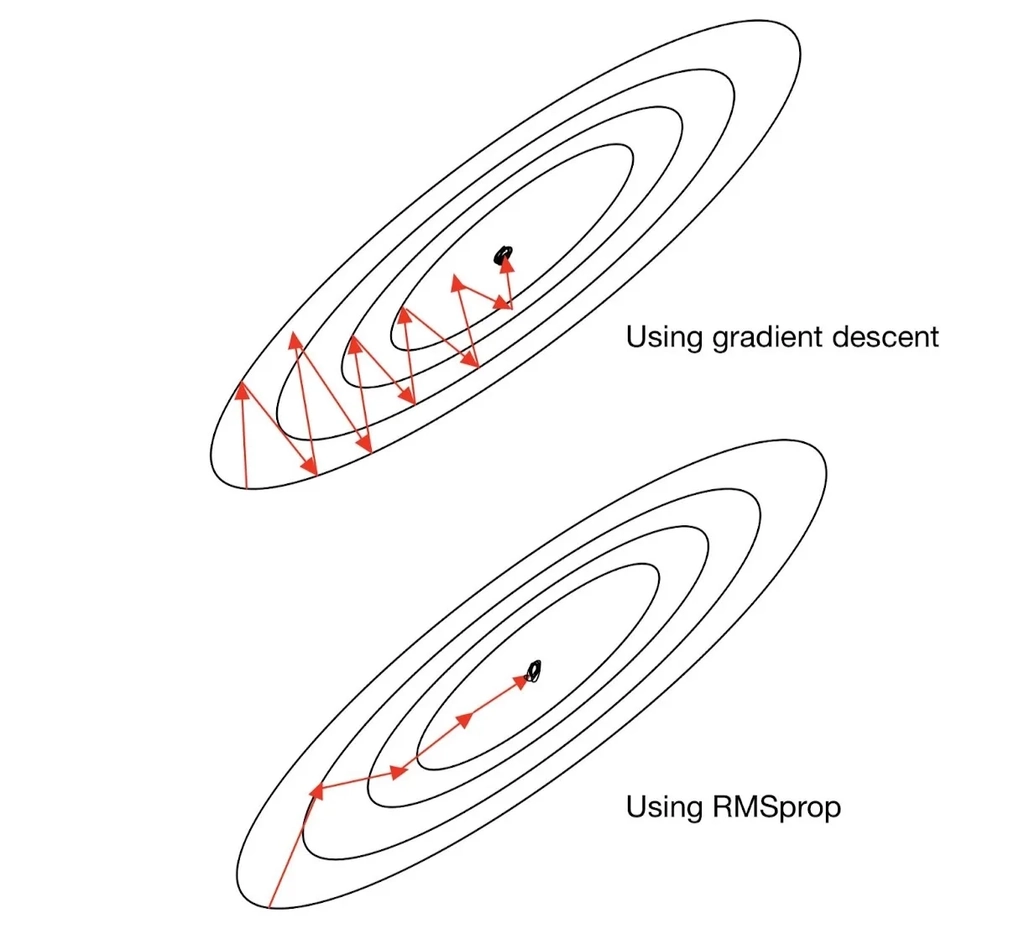  
  
- 최근 기울기를 참고하여, 급한 경사에서는 속도를 줄이고, 완만한 경사에서는 속도를 유지하거나 증가하여 안전하고 효율적으로 하강
  
3. 아담 (Adam): 모멘텀과 RMSProp를 합친, 방향과 스텝 사이즈를 적절하게 합친 방법  
- 방향과 학습률 모두 잡기 위한 방법
- 각 파라미터의 1차 모멘트(기울기의 평균)와 2차 모멘트(기울기의 제곱 평균)을 사용하여 학습률 조정
  

### 2-6. 데이터 증강 (Data Augmentation)  
  
**데이터 증강**: 학습 데이터셋에 일부러 다양한 변화를 가함  
- 목적: 데이터 부족 문제 해결, 모델의 견고함(Robustness) 향상, 과적합 감소
- 적용 분야: 비전(이미지), 자연어 처리
- 주의점: 변형된 데이터가 원본의 본질적인 특성을 잃지 않아야 함. 태스크에 적절한 증강 방식을 선택해야 함.  
  
> 데이터 증강이 구체적으로 도움이 되는 경우  
  
1. 모델 성능의 향상: 다양한 변형 데이터를 학습함으로써 모델이 더욱 일반화된 패턴을 익힘  
2. 데이터 의존성 감소: 다양한 패턴을 학습하여 과적합 방지
3. 과적합 완화: 약간의 변형을 거친 데이터를 추가적으로 학습하게 되어 다양한 입력값 가짐
4. 데이터 프라이버시 보호: 원본 데이터의 노출을 최소화하면서 성능은 향상